# Stage 4: SHAP interactions and GLM-B (D018, D023-D030, D039)

Display only. Run `make all` first; this notebook reads `reports/`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from src.config import load_config

cfg = load_config()
T, F = cfg["paths"]["tables"], cfg["paths"]["figures"]
pd.set_option("display.width", 200)


def show(name):
    plt.figure(figsize=(12, 5))
    plt.imshow(mpimg.imread(F / name))
    plt.axis("off")
    plt.show()

In [2]:
pd.read_csv(T / "shap_interaction_ranking.csv")

,feature_1,feature_2,mean_abs_interaction,sd_interaction,rank,mean_abs_main_effect_1,mean_abs_main_effect_2,friedman_h2
0,DrivAge,BonusMalus,0.075299,0.100658,1,0.150323,0.371840,0.047272
1,BonusMalus,VehBrand,0.046720,0.063259,2,0.371840,0.070453,0.021655
2,BonusMalus,Region,0.045823,0.051639,3,0.371840,0.071652,0.011027
3,BonusMalus,LogDensity,0.035556,0.042411,4,0.371840,0.112384,0.006251
4,DrivAge,LogDensity,0.022460,0.029122,5,0.150323,0.112384,0.021536
5,VehAge,VehBrand,0.021966,0.026139,6,0.094531,0.070453,0.044717
6,DrivAge,VehPower,0.016374,0.021774,7,0.150323,0.041994,0.014348
7,DrivAge,Region,0.015769,0.019601,8,0.150323,0.071652,0.010820
8,VehAge,BonusMalus,0.015660,0.027661,9,0.094531,0.371840,NaN
9,DrivAge,VehBrand,0.015192,0.021996,10,0.150323,0.070453,NaN


In [3]:
pd.read_csv(T / "two_way_ae_summary_glm_a.csv")

,model,factor_1,factor_2,cells,rows,cols,cells_abs_z_gt_1_96,expected_by_chance,sum_z_squared,mean_z_squared,df_rc,z2_per_df_rc,df_incomplete,z2_per_df_incomplete
0,GLM-A,DrivAge_band,BonusMalus_band,88,11,11,33,4.40,388.258917,4.412033,100,3.882589,67,5.794909
1,GLM-A,BonusMalus_band,VehBrand_grp,91,11,10,16,4.55,253.863834,2.789712,90,2.820709,71,3.575547
2,GLM-A,BonusMalus_band,Region_grp,125,11,18,25,6.25,376.454324,3.011635,170,2.214437,97,3.880972
3,GLM-A,BonusMalus_band,LogDensity_band,90,11,9,14,4.50,156.430822,1.738120,80,1.955385,71,2.203251
4,GLM-A,DrivAge_band,LogDensity_band,87,11,9,1,4.35,55.549975,0.638505,80,0.694375,68,0.816911
5,GLM-A,VehAge_band,VehBrand_grp,83,9,10,11,4.15,116.778162,1.406966,72,1.621919,65,1.796587
6,GLM-A,DrivAge_band,VehPower_band,78,11,9,5,3.90,89.751305,1.150658,80,1.121891,59,1.521209
7,GLM-A,DrivAge_band,Region_grp,137,11,18,2,6.85,108.344134,0.790833,170,0.637318,109,0.993983


In [4]:
pd.read_csv(T / "interaction_selection_log.csv")

,candidate,pair,description,n_params,cv_deviance_mean,improvement_mean,improvement_sd,folds_improved,lrt_stat,lrt_df,...,fold_3_improvement,fold_4_improvement,rule1_beyond_noise,rule2_all_folds,rule3_materiality,rule4_stable_sensible,passes,step,region_groups_full_learn,fold_groupings_identical
0,young_lbm_senior_malus,DrivAge x BonusMalus,log(BM/50) slope shift for age <30; step for a...,2,0.238994,0.000267,0.000158,5,148.439130,2,...,0.000369,0.000014,True,True,True,True,True,1,NaN,NaN
1,bm_x_density,BonusMalus x LogDensity,"(BM - 50) x (log density - 5), numeric x numer...",1,0.238932,0.000062,0.000022,5,34.330467,1,...,0.000039,0.000088,True,True,False,True,False,2,NaN,NaN
2,b12_x_bm_linear,BonusMalus x VehBrand,B12 x (BM - 50) (1 param),1,0.238706,0.000288,0.000135,5,161.133371,1,...,0.000478,0.000118,True,True,True,True,True,3,NaN,NaN
3,b12_x_bm_3grp,BonusMalus x VehBrand,"B12 x BM groups 51-99 and 100+, base 50 (2 par...",2,0.238672,0.000321,0.000123,5,180.855000,2,...,0.000491,0.000162,True,True,True,True,True,3,NaN,NaN
4,region_bm_slope_2grp,BonusMalus x Region,log(BM/50) slope by 2 region groups formed on ...,1,0.238534,0.000172,0.000070,5,96.672529,1,...,0.000163,0.000067,True,True,True,True,True,4,"group1: Aquitaine, Haute-Normandie, Ile-de-Fra...",False
5,region_bm_slope_3grp,BonusMalus x Region,log(BM/50) slope by 3 region groups formed on ...,2,0.238527,0.000179,0.000092,5,124.796119,2,...,0.000121,0.000112,True,True,True,True,True,4,"group1: Aquitaine, Haute-Normandie, Ile-de-Fra...",False
6,b12_x_newcar,VehAge x VehBrand,B12 with vehicle age 0-1 (1 param),1,0.238497,0.000037,0.000053,3,24.876358,1,...,0.000110,0.000069,True,False,False,True,False,5,NaN,NaN


In [5]:
pd.read_csv(T / "interaction_accepted.csv")

,step,accepted,pair,improvement_mean,share_of_gap,cv_deviance_after,cumulative_share_of_gap
0,1,young_lbm_senior_malus,DrivAge x BonusMalus,0.000267,0.168917,0.238994,0.168917
1,3,b12_x_bm_linear,BonusMalus x VehBrand,0.000288,0.182286,0.238706,0.351203
2,4,region_bm_slope_2grp,BonusMalus x Region,0.000172,0.109223,0.238534,0.460426


In [6]:
pd.read_csv(T / "gap_closed.csv")

,cv_gap_glm_a_minus_gbm,cv_gap_closed_by_glm_b,holdout_gap_glm_a_minus_gbm,holdout_gap_closed_by_glm_b,n_accepted
0,0.001578,0.411099,0.001907,0.326558,3


In [7]:
pd.read_csv(T / "frequency_model_comparison.csv")

,model,n_params,cv_deviance_mean,cv_deviance_sd,cv_fold_0,cv_fold_1,cv_fold_2,cv_fold_3,cv_fold_4,holdout_deviance,holdout_gini,holdout_predicted_over_actual
0,Intercept only,1,0.252058,0.003117,0.254593,0.248683,0.253992,0.254401,0.248620,0.255160,0.000000,0.986858
1,GLM-A (current tariff),72,0.239260,0.003246,0.242192,0.236385,0.240904,0.241662,0.235158,0.242651,0.293981,0.982392
2,GLM-B (proposed tariff),73,0.238611,0.003004,0.241451,0.235663,0.240216,0.240662,0.235066,0.242028,0.301734,0.982688
3,GBM (LightGBM Poisson),565,0.237682,0.003109,0.240851,0.234626,0.239102,0.239752,0.234081,0.240744,0.315830,0.983453
4,GLM-A-mono (impact baseline),69,0.239374,0.003226,0.242247,0.236533,0.241097,0.241720,0.235272,0.242727,0.293326,0.982271


In [8]:
pd.read_csv(T / "bm_monotonicity_steps.csv")

,bands,effective,cv_deviance_mean,cv_deviance_sd,n_params,monotone,merge_next
0,50 | 51-55 | 56-60 | 61-65 | 66-70 | 71-75 | 7...,1.000 | 1.332 | 1.612 | 2.675 | 1.859 | 2.069 ...,0.238534,0.003023,76,False,61-65 + 66-70 -> 61-70
1,50 | 51-55 | 56-60 | 61-70 | 71-75 | 76-80 | 8...,1.000 | 1.332 | 1.612 | 2.327 | 2.069 | 2.012 ...,0.238617,0.003004,75,False,61-70 + 71-75 -> 61-75
2,50 | 51-55 | 56-60 | 61-75 | 76-80 | 81-90 | 9...,1.000 | 1.332 | 1.612 | 2.254 | 2.012 | 2.193 ...,0.238615,0.003004,74,False,61-75 + 76-80 -> 61-80
3,50 | 51-55 | 56-60 | 61-80 | 81-90 | 91-99 | 1...,1.000 | 1.332 | 1.612 | 2.180 | 2.193 | 2.870 ...,0.238611,0.003004,73,True,NaN


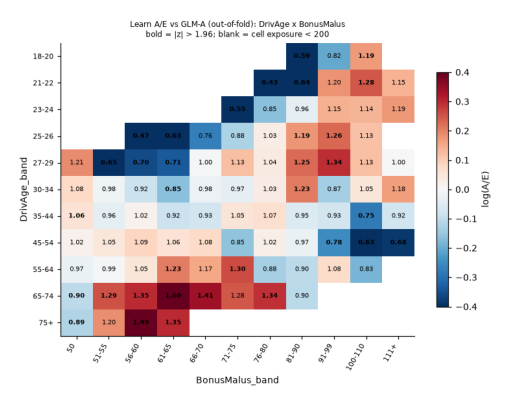

In [9]:
show("ae_heatmap_DrivAge_x_BonusMalus.png")

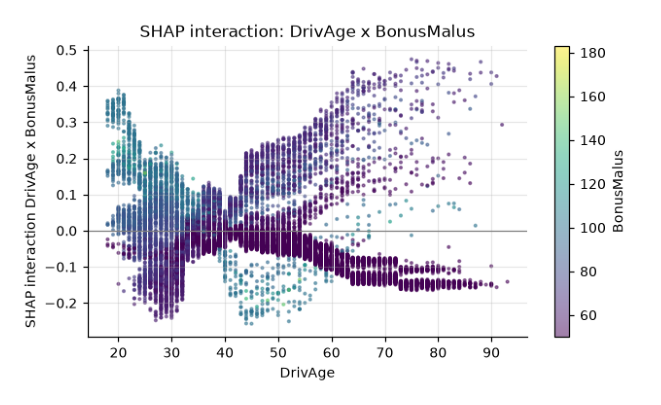

In [10]:
show("shap_dependence_DrivAge_x_BonusMalus.png")

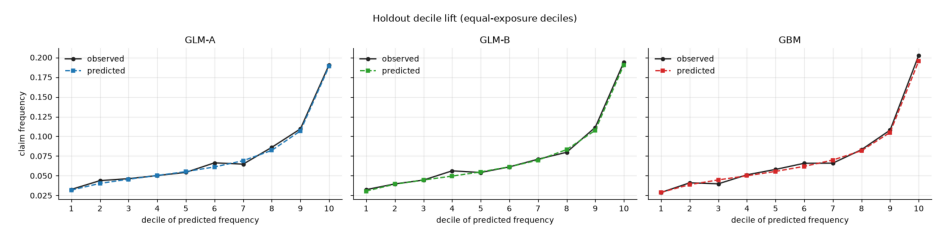

In [11]:
show("lift_holdout.png")